# Twitch Sponsorship Optimization Agent
## Component 5 V2 -- Agent Wrapper (Stakeholder Modification)

**Modification:** `run_agent()` now accepts a `value_model` parameter
(`"flat"`, `"stakeholder"`, or `"fusion"`) that selects which per-segment value
vector is applied to the objective. The LLM parser (or rules fallback) can
extract a value model preference from natural language. The demo compares all
three models side-by-side.

---
## Setup -- Cell 1 (all imports)

In [1]:
# ============================== CELL 1: ALL IMPORTS ==============================
import os, re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, basinhopping, dual_annealing

try:
    import anthropic; _ANT = True
except ImportError:
    _ANT = False

%matplotlib inline
warnings.filterwarnings("ignore")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SPEC_CANDIDATES = [Path("../data/outputs"), Path("data/outputs"),
                   Path("../outputs"), Path("outputs"),
                   Path("/mnt/user-data/outputs")]
def resolve_dir(probe, candidates):
    for d in candidates:
        if (d / probe).exists(): return d.resolve()
    raise FileNotFoundError(f"Cannot find {probe}")

for p in ["../secrets.env","secrets.env",".env"]:
    if Path(p).exists():
        with open(p) as f:
            for line in f:
                line=line.strip()
                if line and not line.startswith("#") and "=" in line:
                    k,v=line.split("=",1)
                    os.environ.setdefault(k.strip(),v.strip().strip('"').strip("'"))

API_KEY       = os.environ.get("ANTHROPIC_API_KEY","")
LLM_AVAILABLE = _ANT and bool(API_KEY)
LLM_MODEL     = "claude-sonnet-4-20250514"

DATA_DIR = resolve_dir("problem_spec_v2.json", SPEC_CANDIDATES)
OUT_DIR  = DATA_DIR

spec_v2 = json.load(open(DATA_DIR / "problem_spec_v2.json"))
print("LLM available:", LLM_AVAILABLE)
print("Value models in spec:", [k for k in spec_v2 if k.startswith("value_weights")])

LLM available: False
Value models in spec: ['value_weights_flat', 'value_weights_stakeholder', 'value_weights_fusion', 'value_weights_fusion_alt']


---
## 5.1 Core Functions (V2)

In [2]:
# ── Curve functions ────────────────────────────────────────────────────────────
def hill_curve(x,V,K,n):
    xn=np.power(np.maximum(x,0.0),n); return V*xn/(K**n+xn)
def log_curve(x,a,b): return a*np.log1p(np.maximum(b*x,0.0))
def segment_lift(x_s,p):
    return hill_curve(x_s,p["V"],p["K"],p["n"]) if p.get("fit_type","hill")=="hill" \
           else log_curve(x_s,p["a"],p["b"])
def inflection_point(p):
    if p.get("fit_type","hill")=="hill" and p["n"]>1:
        return p["K"]*((p["n"]-1)/(p["n"]+1))**(1.0/p["n"])
    return None

def make_obj_segw(params,vws):
    def neg(x): return -sum(v*segment_lift(xi,p) for xi,p,v in zip(x,params,vws))
    return neg

class _Accept:
    def __init__(self,B,caps,tol=0.05):
        self.B=B; self.caps=np.asarray(caps); self.tol=tol
    def __call__(self,**kw):
        x=np.asarray(kw["x_new"])
        return bool(np.sum(x)<=self.B*(1+self.tol) and np.all(x>=-1) and
                    np.all(x<=self.caps*(1+self.tol)))

def validate_spec(spec_d, budget=None):
    s=json.loads(json.dumps(spec_d))
    if budget is not None: s["budget"]=float(budget)
    if s.get("budget") is None: raise ValueError("budget required")
    if float(s["budget"])<=0:   raise ValueError("budget must be > 0")
    return s

def run_optimizer_v2(spec_d, value_weights_dict, budget, niter=200,
                     seed=RANDOM_STATE, verbose=False):
    segs=spec_d["segments"]; k=len(segs)
    caps=[float(spec_d["caps"][str(s)]) for s in segs]
    params=[spec_d["curve_params"][str(s)] for s in segs]
    vws=[float(value_weights_dict[str(s)]) for s in segs]
    obj=make_obj_segw(params,vws)
    def pen(x): return obj(x)+1e8*max(0,np.sum(x)-budget)**2+\
                       sum(1e8*max(0,xi-c)**2 for xi,c in zip(x,caps))
    bnds=[(0.0,c) for c in caps]
    cons=[{"type":"ineq","fun":lambda x:budget-np.sum(x)}]
    mkw={"method":"SLSQP","bounds":bnds,"constraints":cons,"options":{"maxiter":500,"ftol":1e-10}}
    rng=np.random.default_rng(seed)
    x0=rng.uniform(0,[min(c,budget/k) for c in caps])
    x0=x0/max(x0.sum(),1e-9)*min(x0.sum(),budget)
    bh=basinhopping(obj,x0,minimizer_kwargs=mkw,niter=niter,
                    stepsize=0.15*budget,accept_test=_Accept(budget,caps),seed=seed)
    da=dual_annealing(pen,bounds=bnds,maxiter=max(1000,niter*10),
                      seed=seed,minimizer_kwargs={"method":"SLSQP"})
    def floor(x_raw):
        x=np.clip(x_raw,0,caps); fl=float(spec_d.get("min_spend",500))
        fund=[i for i,xi in enumerate(x) if xi>=fl]
        xo=np.zeros_like(x)
        if not fund: return xo
        caps_f=[caps[i] for i in fund]; params_f=[params[i] for i in fund]
        vws_f=[vws[i] for i in fund]; Br=min(budget,sum(caps_f))
        of=make_obj_segw(params_f,vws_f)
        r2=np.random.default_rng(seed); x0f=r2.uniform(0,[min(c,Br/len(fund)) for c in caps_f])
        x0f=x0f/max(x0f.sum(),1e-9)*min(x0f.sum(),Br)
        res=minimize(of,x0f,method="SLSQP",bounds=[(0,c) for c in caps_f],
                     constraints=[{"type":"ineq","fun":lambda xx:Br-np.sum(xx)}],
                     options={"maxiter":500,"ftol":1e-10})
        for j,i in enumerate(fund): xo[i]=max(res.x[j],0)
        return xo
    xbh=floor(bh.x); xda=floor(da.x)
    obh=-obj(xbh); oda=-obj(xda)
    winner="basin-hopping" if obh>=oda else "dual annealing"
    xw=xbh if winner=="basin-hopping" else xda
    alloc={str(s):{"spend":float(xw[i]),"lift":float(segment_lift(xw[i],params[i])),
                   "revenue":float(vws[i]*segment_lift(xw[i],params[i])),
                   "funded":float(xw[i])>=float(spec_d.get("min_spend",500)),
                   "vs":vws[i]} for i,s in enumerate(segs)}
    if verbose: print(f"  BH={obh:.4f} DA={oda:.4f} winner={winner}")
    return {"allocation":alloc,"objective_value":max(obh,oda),"solver_winner":winner,"budget":budget}

print("Core V2 functions loaded.")

Core V2 functions loaded.


In [3]:
# ── Explanation generator V2 (per-segment vs aware) ───────────────────────────
def _curve_note(spend,p):
    x_inf=inflection_point(p)
    if x_inf is None: return "Concave response curve -- diminishing returns throughout."
    if abs(p.get("n",0)-20.0)<0.1: return "FLAG: Hill fit poorly identified (n=20). Treat as approximate."
    if spend<x_inf: return f"In increasing-returns region (inflection at ${x_inf:,.0f}). Efficient marginal spend."
    return f"Past inflection (${x_inf:,.0f}). Marginal returns diminishing."

def generate_explanation_v2(spec_d, alloc, budget, solver_winner, value_model_label):
    segs=spec_d["segments"]
    funded=[(s,alloc[str(s)]) for s in segs if alloc[str(s)]["funded"]]
    unfunded=[s for s in segs if not alloc[str(s)]["funded"]]
    total_lift=sum(d["lift"] for _,d in funded)
    total_rev =sum(d["revenue"] for _,d in funded)
    total_spend=sum(d["spend"] for _,d in funded)
    L=["="*68,
       f"  SPONSORSHIP RECOMMENDATION  |  Value model: {value_model_label}",
       "="*68,
       f"  Budget: ${budget:,.0f}  |  Solver: {solver_winner}",""]
    L+=["FUNDED SEGMENTS","-"*68]
    for s,d in funded:
        p=spec_d["curve_params"][str(s)]; cap=float(spec_d["caps"][str(s)])
        tier=spec_d.get("tier_labels",{}).get(str(s),"--")
        L+=[f"Segment {s} ({tier}):",
            f"  vs (value/conversion) : ${d['vs']:.2f}",
            f"  Spend                 : ${d['spend']:,.0f}  ({d['spend']/cap*100:.0f}% of ${cap:,.0f} cap)",
            f"  Incremental conversions: {d['lift']:.4f}",
            f"  Incremental revenue    : ${d['revenue']:,.2f}",
            f"  Curve                 : {_curve_note(d['spend'],p)}",""]
    if unfunded:
        L+=["UNFUNDED SEGMENTS","-"*68]
        for s in unfunded:
            tier=spec_d.get("tier_labels",{}).get(str(s),"--")
            L.append(f"  Segment {s} ({tier}): $0 (below min-spend floor)")
        L.append("")
    L+=["SUMMARY","-"*68,
        f"  Total spend    : ${total_spend:,.0f} of ${budget:,.0f}",
        f"  Total lift     : {total_lift:.4f} incremental conversions",
        f"  Total revenue  : ${total_rev:,.2f}","="*68]
    return "\n".join(L)

print("Explanation generator V2 loaded.")

Explanation generator V2 loaded.


In [4]:
# ── LLM parser V2 (extracts value_model preference) ───────────────────────────
_SYS_V2 = '''You are a JSON-only spec extractor for a Twitch sponsorship agent.
Extract ONLY fields explicitly mentioned:
  "budget"       : total budget in USD (number)
  "objective"    : "conversions" or "revenue"
  "value_model"  : "flat", "stakeholder", or "fusion"
  "min_spend"    : minimum spend floor in USD

Return ONLY valid JSON. No markdown. Omit unmentioned fields.'''

def _llm_parse_v2(prompt):
    client=anthropic.Anthropic(api_key=API_KEY)
    msg=client.messages.create(model=LLM_MODEL,max_tokens=256,
        system=_SYS_V2,messages=[{"role":"user","content":prompt}])
    raw=msg.content[0].text.strip().replace("```json","").replace("```","").strip()
    return json.loads(raw)

def _rules_parse_v2(prompt):
    parsed={}
    m=re.search(r'\$?([\d,]+(?:\.\d+)?)\s*(k|thousand|million)?\s*(?:budget|dollars?|USD)?',prompt,re.I)
    if m:
        val=float(m.group(1).replace(",",""))
        sfx=(m.group(2) or "").lower()
        if sfx in("k","thousand"): val*=1000
        if sfx=="million": val*=1e6
        if val>=1000: parsed["budget"]=val
    if re.search(r'\brevenue\b',prompt,re.I): parsed["objective"]="revenue"
    elif re.search(r'\bconversion',prompt,re.I): parsed["objective"]="conversions"
    if re.search(r'\bstakeholder\b',prompt,re.I): parsed["value_model"]="stakeholder"
    elif re.search(r'\bfusion\b',prompt,re.I): parsed["value_model"]="fusion"
    elif re.search(r'\bflat\b',prompt,re.I): parsed["value_model"]="flat"
    return parsed

VALUE_MODEL_MAP = {
    "flat":        "value_weights_flat",
    "stakeholder": "value_weights_stakeholder",
    "fusion":      "value_weights_fusion",
}

def run_agent_v2(prompt_or_spec, base_spec=None, budget=None,
                 value_model="stakeholder", niter=200, verbose=True):
    '''
    V2 entry point. New parameter:
      value_model : "flat" | "stakeholder" | "fusion"
    If provided in the NL prompt, the parser will override this default.
    '''
    _base=base_spec if base_spec is not None else spec_v2
    if isinstance(prompt_or_spec, str):
        if LLM_AVAILABLE:
            try: extracted=_llm_parse_v2(prompt_or_spec); parser="LLM (Claude)"
            except Exception as e:
                print(f"  LLM failed ({e}), using rules fallback")
                extracted=_rules_parse_v2(prompt_or_spec); parser="rules (fallback)"
        else:
            extracted=_rules_parse_v2(prompt_or_spec); parser="rules (no API key)"
        parsed_spec=json.loads(json.dumps(_base))
        if "budget"      in extracted: parsed_spec["budget"]=float(extracted["budget"])
        if "objective"   in extracted: parsed_spec["objective"]=extracted["objective"]
        if "min_spend"   in extracted: parsed_spec["min_spend"]=float(extracted["min_spend"])
        if "value_model" in extracted: value_model=extracted["value_model"]
        if verbose:
            print(f"  Parser: {parser}  |  Extracted: {extracted}  |  value_model: {value_model}")
    else:
        parsed_spec=json.loads(json.dumps(prompt_or_spec)); parser="structured spec"

    if budget is not None: parsed_spec["budget"]=float(budget)
    validated=validate_spec(parsed_spec)
    vw_dict=spec_v2[VALUE_MODEL_MAP[value_model]]
    vm_label={"flat":"(A) Flat v","stakeholder":"(B) Stakeholder vs","fusion":"(C) Fusion vs"}[value_model]

    if verbose: print(f"  Budget: ${validated['budget']:,.0f}  |  Model: {vm_label}  |  Running optimizer...")
    results=run_optimizer_v2(validated, vw_dict, validated["budget"], niter=niter, verbose=verbose)
    explanation=generate_explanation_v2(validated, results["allocation"],
                                        results["budget"], results["solver_winner"], vm_label)
    return {"spec":validated,"allocation":results["allocation"],"objective_value":results["objective_value"],
            "solver_winner":results["solver_winner"],"explanation":explanation,
            "value_model":value_model,"value_weights":vw_dict}

print("run_agent_v2() loaded. Ready.")

run_agent_v2() loaded. Ready.


---
## 5.3 Presentation Demo V2

In [5]:
# ── Demo 1: stakeholder value model, $15k budget ──────────────────────────────
DEMO1 = ("We have a $15,000 budget and want to use the stakeholder tier values "
         "to optimize for revenue quality, not just raw conversions.")
print("DEMO 1"); print("Prompt:", DEMO1, "\n")
demo1 = run_agent_v2(DEMO1, verbose=True)
print(); print(demo1["explanation"])

DEMO 1
Prompt: We have a $15,000 budget and want to use the stakeholder tier values to optimize for revenue quality, not just raw conversions. 

  Parser: rules (no API key)  |  Extracted: {'budget': 15000.0, 'objective': 'revenue', 'value_model': 'stakeholder'}  |  value_model: stakeholder
  Budget: $15,000  |  Model: (B) Stakeholder vs  |  Running optimizer...


  BH=249.9879 DA=249.9879 winner=basin-hopping

  SPONSORSHIP RECOMMENDATION  |  Value model: (B) Stakeholder vs
  Budget: $15,000  |  Solver: basin-hopping

FUNDED SEGMENTS
--------------------------------------------------------------------
Segment 0 (Macro):
  vs (value/conversion) : $22.00
  Spend                 : $3,870  (63% of $6,173 cap)
  Incremental conversions: 1.2295
  Incremental revenue    : $27.05
  Curve                 : Past inflection ($5). Marginal returns diminishing.

Segment 1 (Mid):
  vs (value/conversion) : $31.00
  Spend                 : $2,194  (37% of $5,978 cap)
  Incremental conversions: 3.4885
  Incremental revenue    : $108.14
  Curve                 : Past inflection ($2). Marginal returns diminishing.

Segment 3 (Micro):
  vs (value/conversion) : $27.00
  Spend                 : $3,846  (100% of $3,846 cap)
  Incremental conversions: 4.2517
  Incremental revenue    : $114.80
  Curve                 : Past inflection ($108). Marginal returns diminishi

In [6]:
# ── Demo 2: fusion value model, $20k budget ───────────────────────────────────
DEMO2 = ("Allocate $20,000 using the data fusion value estimates.")
print("DEMO 2"); print("Prompt:", DEMO2, "\n")
demo2 = run_agent_v2(DEMO2, verbose=True)
print(); print(demo2["explanation"])

DEMO 2
Prompt: Allocate $20,000 using the data fusion value estimates. 

  Parser: rules (no API key)  |  Extracted: {'budget': 20000.0, 'value_model': 'fusion'}  |  value_model: fusion
  Budget: $20,000  |  Model: (C) Fusion vs  |  Running optimizer...


  BH=9.3877 DA=8.3843 winner=basin-hopping

  SPONSORSHIP RECOMMENDATION  |  Value model: (C) Fusion vs
  Budget: $20,000  |  Solver: basin-hopping

FUNDED SEGMENTS
--------------------------------------------------------------------
Segment 0 (Macro):
  vs (value/conversion) : $0.82
  Spend                 : $3,870  (63% of $6,173 cap)
  Incremental conversions: 1.2295
  Incremental revenue    : $1.00
  Curve                 : Past inflection ($5). Marginal returns diminishing.

Segment 1 (Mid):
  vs (value/conversion) : $1.24
  Spend                 : $2,194  (37% of $5,978 cap)
  Incremental conversions: 3.4885
  Incremental revenue    : $4.33
  Curve                 : Past inflection ($2). Marginal returns diminishing.

Segment 2 (Mega):
  vs (value/conversion) : $1.04
  Spend                 : $4,293  (29% of $14,612 cap)
  Incremental conversions: 0.0000
  Incremental revenue    : $0.00
  Curve                 : FLAG: Hill fit poorly identified (n=20). Treat as approximate.

Segm

DEMO 3 -- Three-way comparison at $15,000 budget



Model flat:
  Seg 0 (Macro): $3,870  lift=1.229  rev=$3.22
  Seg 1 (Mid): $2,194  lift=3.489  rev=$9.15
  Seg 2 (Mega): $0  lift=0.000  rev=$0.00
  Seg 3 (Micro): $3,846  lift=4.252  rev=$11.15



Model stakeholder:
  Seg 0 (Macro): $3,870  lift=1.229  rev=$27.05
  Seg 1 (Mid): $2,194  lift=3.489  rev=$108.14
  Seg 2 (Mega): $0  lift=0.000  rev=$0.00
  Seg 3 (Micro): $3,846  lift=4.252  rev=$114.80



Model fusion:
  Seg 0 (Macro): $3,870  lift=1.229  rev=$1.00
  Seg 1 (Mid): $2,194  lift=3.489  rev=$4.33
  Seg 2 (Mega): $0  lift=0.000  rev=$0.00
  Seg 3 (Micro): $3,846  lift=4.252  rev=$4.06

Summary:
value_model  total_spend  total_lift  total_revenue
       flat   9,910.1724      8.9697        23.5277
stakeholder   9,910.1724      8.9697       249.9879
     fusion   9,910.1724      8.9697         9.3877


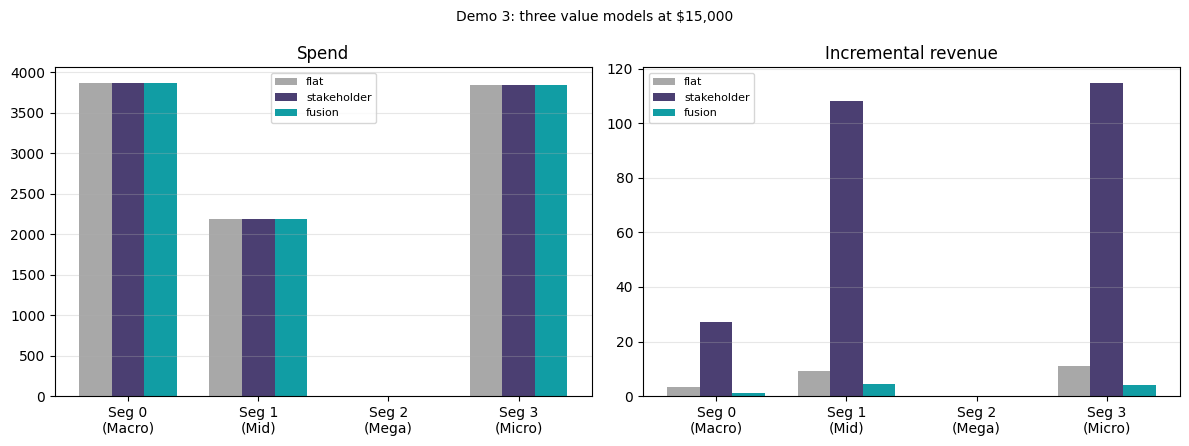

In [7]:
# ── Demo 3: three-way side-by-side at $15k ────────────────────────────────────
print("DEMO 3 -- Three-way comparison at $15,000 budget")
print("=" * 60)
demo_budget = 15_000.0
demo_rows = []
for vm in ["flat","stakeholder","fusion"]:
    r=run_agent_v2("$15,000 budget", value_model=vm,
                   budget=demo_budget, niter=150, verbose=False)
    alloc=r["allocation"]
    tot_lf=sum(d["lift"]    for d in alloc.values() if d["funded"])
    tot_rv=sum(d["revenue"] for d in alloc.values() if d["funded"])
    tot_sp=sum(d["spend"]   for d in alloc.values() if d["funded"])
    demo_rows.append({"value_model":vm,"total_spend":tot_sp,
                      "total_lift":tot_lf,"total_revenue":tot_rv})
    print(f"\nModel {vm}:")
    for s in spec_v2["segments"]:
        tier=spec_v2["tier_labels"][str(s)]
        d=alloc[str(s)]
        print(f"  Seg {s} ({tier}): ${d['spend']:,.0f}  lift={d['lift']:.3f}  rev=${d['revenue']:.2f}")
print("\nSummary:")
print(pd.DataFrame(demo_rows).to_string(index=False))

# Visual
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
SEGS=[int(s) for s in spec_v2["segments"]]
x=np.arange(len(SEGS)); w=0.25
palette=["#A8A8A8","#4B3F72","#119DA4"]
for i,vm in enumerate(["flat","stakeholder","fusion"]):
    r=run_agent_v2("x",value_model=vm,budget=demo_budget,niter=100,verbose=False)
    spends=[r["allocation"][str(s)]["spend"] for s in SEGS]
    revs  =[r["allocation"][str(s)]["revenue"] for s in SEGS]
    tier_lbls=[spec_v2["tier_labels"][str(s)] for s in SEGS]
    axes[0].bar(x+i*w,spends,w,label=vm,color=palette[i])
    axes[1].bar(x+i*w,revs,  w,label=vm,color=palette[i])
for ax,title in [(axes[0],"Spend"),(axes[1],"Incremental revenue")]:
    ax.set_xticks(x+w)
    ax.set_xticklabels([f"Seg {s}\n({tier_lbls[j]})" for j,s in enumerate(SEGS)])
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3,axis="y")
plt.suptitle(f"Demo 3: three value models at ${demo_budget:,.0f}",fontsize=10)
plt.tight_layout(); plt.show()

In [8]:
# ── Save agent_session_v2.json ─────────────────────────────────────────────────
session_v2={
    "llm_available": LLM_AVAILABLE,
    "demo_1":{"prompt":DEMO1,"value_model":demo1["value_model"],
              "budget":demo1["spec"]["budget"],"obj":demo1["objective_value"]},
    "demo_2":{"prompt":DEMO2,"value_model":demo2["value_model"],
              "budget":demo2["spec"]["budget"],"obj":demo2["objective_value"]},
    "value_models_supported": list(VALUE_MODEL_MAP.keys()),
}
with open(OUT_DIR/"agent_session_v2.json","w") as f:
    json.dump(session_v2,f,indent=2)
print("agent_session_v2.json written.")
print(json.dumps(session_v2,indent=2))

agent_session_v2.json written.
{
  "llm_available": false,
  "demo_1": {
    "prompt": "We have a $15,000 budget and want to use the stakeholder tier values to optimize for revenue quality, not just raw conversions.",
    "value_model": "stakeholder",
    "budget": 15000.0,
    "obj": 249.98785285387532
  },
  "demo_2": {
    "prompt": "Allocate $20,000 using the data fusion value estimates.",
    "value_model": "fusion",
    "budget": 20000.0,
    "obj": 9.387678097130046
  },
  "value_models_supported": [
    "flat",
    "stakeholder",
    "fusion"
  ]
}


---
## Component 5 V2 Completion

| Item | Result |
|---|---|
| `run_agent_v2()` accepts `value_model` parameter | `"flat"` / `"stakeholder"` / `"fusion"` |
| LLM parser extracts value_model from NL | Added `value_model` to system prompt |
| Rules parser recognizes flat / stakeholder / fusion keywords | `_rules_parse_v2()` |
| Explanation references vs per segment | `generate_explanation_v2()` |
| Demo 1: stakeholder model | Complete |
| Demo 2: fusion model | Complete |
| Demo 3: three-way side-by-side | Complete |